In [4]:
import torch as tr
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tiktoken as ttk
import numpy as np
import matplotlib.pyplot as pl
import pandas as pd
import sys
import os

# Get the path of the directory you want to import from
module_dir = [os.path.relpath('GPT_architecture'), os.path.relpath('data')]

# Add the directory to the system path
for direc in module_dir:
    if direc not in sys.path:
        sys.path.append(direc)

print(sys.path)
# Now you can import the module as if it were in the current directory

import GPT_modules as gpt

GPT_CONFIG_124M = {
"vocab_size": 50257, # Vocabulary size
"context_length": 256, # Context length
"emb_dim": 768, # Embedding dimension
"n_heads": 12, # Number of attention heads
"n_layers": 12, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": True # Query-Key-Value bias
}

tokenizer = ttk.get_encoding("gpt2")
gpt_model = gpt.GPTModule(GPT_CONFIG_124M)
gpt_model.eval()


['/Library/Frameworks/Python.framework/Versions/3.10/lib/python310.zip', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/lib-dynload', '', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages', 'GPT_architecture', 'data']


GPTModule(
  (Token_Embedding): Embedding(50257, 768)
  (Position_Embedding): Embedding(256, 768)
  (Dropout_bef_Transform): Dropout(p=0.1, inplace=False)
  (Transformer_block): Sequential(
    (0): Transformer(
      (Layer_norm1): LayerNormalization()
      (Layer_norm2): LayerNormalization()
      (Multihead_attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (FFN): FFN(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (Dropout): Dropout(p=0.1, inplace=False)
    )
    (1): Transforme

In [ ]:
import urllib.request
import zipfile
import os
from pathlib import Path

In [ ]:
## downloading the sms spam collection file
# 
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url,zip_path,extracted_path,data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists")
        return
    
    with urllib.request.urlopen(url) as open_url:
        with open(zip_path,"wb") as open_file:
            open_file.write(open_url.read())

    with zipfile.ZipFile(zip_path,'r') as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path)/"SMSSpamCollection"
    os.rename(original_file_path,data_file_path)
    print(f"File downloaded and saved as {original_file_path}")

download_and_unzip_spam_data(url,zip_path,extracted_path,data_file_path)

In [3]:
data_file_path = "data/sms_spam_collection/SMSSpamCollection.tsv"
sms_df = pd.read_csv(data_file_path,sep="\t",header=None, names=['Label','Text'])

In [4]:
sms_df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
print(sms_df['Label'].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
# def create_balanced_dataset(df):
num_spam = (sms_df['Label'] == 'spam').sum()
not_spam_subset = sms_df[sms_df['Label']=='ham'].sample(n=num_spam,random_state=0)

balanced_df = pd.concat((not_spam_subset,sms_df[sms_df['Label']=='spam']))
balanced_df['Label'].value_counts()

Label
ham     747
spam    747
Name: count, dtype: int64

In [ ]:
balanced_df = balanced_df.sample(n=num_spam,random_state=0)
train_ind = 500
train_df = balanced_df[:train_ind]
test_df = balanced_df[train_ind:]
balanced_df["Label"] = balanced_df["Label"].map({"ham":0,"spam":1})

In [5]:
tokenizer = ttk.get_encoding('gpt2')
tokenizer.encode('<|endoftext|>',allowed_special={'<|endoftext|>'})

[50256]

In [ ]:
def random_split(df, train_frac, validation_frac):

    df = df.sample(frac=1, random_state=100).reset_index(drop=True)
    size_df = df.shape[0]
    train_ind = int(size_df*train_frac)
    validation_ind = train_ind + int(size_df*validation_frac)

    train_df = df[:train_ind]
    validation_df = df[train_ind:validation_ind]
    test_df = df[validation_ind:]
    
    return train_df, validation_df, test_df

In [ ]:
balanced_df.sample(frac=1, random_state=100).reset_index(drop=True)
balanced_df.shape
int(3.3), balanced_df[:30]
train_df, validation_df, test_df = random_split(balanced_df,0.7,0.1)
# validation_df, test_df
train_df.to_csv("sms_train.csv",index=None)
validation_df.to_csv("sms_validation.csv",index=None)
test_df.to_csv("sms_test.csv",index=None)

In [6]:
import auxiliary_functions

train_dataset = auxiliary_functions.SpamDataset("data/sms_spam_collection/sms_train.csv",tokenizer)
validation_dataset = auxiliary_functions.SpamDataset("data/sms_spam_collection/sms_validation.csv",tokenizer)
test_dataset = auxiliary_functions.SpamDataset("data/sms_spam_collection/sms_test.csv",tokenizer)


In [7]:
train_dataset.data

,Label,Text
0,1,+123 Congratulations - in this week's competit...
1,1,Jamster! To get your free wallpaper text HEART...
2,1,Rock yr chik. Get 100's of filthy films &XXX p...
3,1,Sunshine Quiz Wkly Q! Win a top Sony DVD playe...
4,0,"Mum, i've sent you many many messages since i ..."
...,...,...
517,0,Have a great trip to India. And bring the ligh...
518,0,I uploaded mine to Facebook
519,1,"SMS. ac JSco: Energy is high, but u may not kn..."
520,1,HOT LIVE FANTASIES call now 08707500020 Just 2...


In [8]:
# # len(tokenizer.encode(train_df["text"].describe().top))
# len(tokenizer.encode(train_df.loc[0,"text"]))
batch_size = 8
num_workers = 0
tr.manual_seed(111)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=num_workers,
                          drop_last=True)

validation_loader = DataLoader(dataset=validation_dataset,
                                batch_size=batch_size,
                                shuffle=True,
                                num_workers=num_workers,
                                drop_last=True)

test_loader = DataLoader(dataset=test_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=num_workers,
                          drop_last=True)

In [17]:
# tr.ones((train_df.shape[0],500))*500
# for i in test_df["text"]:
#     print(tr.tensor(tokenizer.encode(i)))
# train_df
for inp,opt in train_loader:
    pass
inp.shape,opt

(torch.Size([8, 87]), tensor([1, 0, 0, 0, 0, 1, 1, 0]))

In [ ]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M",models_dir="gpt2")

GPT_CONFIG_124M = {
"vocab_size": 50257, # Vocabulary size
"context_length": 1024, # Context length
"emb_dim": 768, # Embedding dimension
"n_heads": 12, # Number of attention heads
"n_layers": 12, # Number of layers
"drop_rate": 0.0, # Dropout rate
"qkv_bias": True # Query-Key-Value bias
}


In [9]:
import tensorflow as tf 
import json
from gpt_download import load_gpt2_params_from_tf_ckpt

model_dir = "gpt2/124M"
tf_ckpt_path = tf.train.latest_checkpoint(model_dir)

settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

In [10]:
model = gpt.GPTModule(GPT_CONFIG_124M)
# model
auxiliary_functions.load_weights_into_model(model,params)

 
input_sentence = "Every thing"
# # top_k = 3
text_gen = auxiliary_functions.generate(input_sentence, tokenizer, model, GPT_CONFIG_124M["context_length"], temperature=2, max_length_text=10, top_k=3)
print(text_gen)

Every thing, though, was the fact that he was a


In [11]:
model.Final_output = nn.Linear(in_features=768, out_features=2, bias=False)
print(model)

GPTModule(
  (Token_Embedding): Embedding(50257, 768)
  (Position_Embedding): Embedding(256, 768)
  (Dropout_bef_Transform): Dropout(p=0.1, inplace=False)
  (Transformer_block): Sequential(
    (0): Transformer(
      (Layer_norm1): LayerNormalization()
      (Layer_norm2): LayerNormalization()
      (Multihead_attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (FFN): FFN(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (Dropout): Dropout(p=0.1, inplace=False)
    )
    (1): Transforme

In [12]:
##freeze the weights of model
for param in model.parameters():
    param.requires_grad = False

## unfreeze the last transformer block and the final output layer for training
for param in model.Transformer_block[-1].parameters():
    param.requires_grad = True
for param in model.Final_Layer_Norm.parameters():
    param.requires_grad = True
for param in model.Final_output.parameters():
    param.requires_grad = True

In [13]:
## checking the freezed params
for param in model.Transformer_block[-2].parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


In [47]:
inp = tokenizer.encode("Do you know what")
inp = tr.tensor(inp).unsqueeze(dim=0)
with tr.no_grad():
    out = model(inp)
out

tensor([[[ 1.8779, -1.0366],
         [ 2.7265, -0.4277],
         [ 4.7048, -0.4029],
         [ 4.6412,  0.2547]]])

In [42]:
pred_label = tr.argmax(out[:,-1,:])
pred_label.item()

0

In [14]:
def calc_accuracy_loader(data_loader, model, num_batches=None):
    model.eval()
    correct_pred, num_examples = 0, 0

    if num_batches == None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches,len(data_loader))

    with tr.no_grad():
        correct_pred = 0
        for inp, label in data_loader:
            out = model(inp)
            pred_labels_batch = tr.argmax(out[:,-1,:],dim=1)
            correct_pred += (pred_labels_batch == label).sum().item()
            num_examples += len(label)
    
    return correct_pred/num_examples

train_acc = calc_accuracy_loader(train_loader,model)
valid_acc = calc_accuracy_loader(validation_loader,model)
test_acc = calc_accuracy_loader(test_loader,model)
print("accuracies of raw GPT-2 model")
print(f"Training acc. : {100*train_acc:0.4f}% , Validation acc. : {100*valid_acc:0.4f}%, Test acc. : {100*test_acc:0.4f}%")

accuracies of raw GPT-2 model
Training acc. : 50.1923% , Validation acc. : 54.1667%, Test acc. : 45.1389%


In [ ]:
# print(nn.functional.cross_entropy(model(inp)[:,-1,:],opt))
# ll = 0
# for i,j in zip(model(inp)[:,-1,:],opt):
#     ll += nn.functional.cross_entropy(i,j)
# ll/8
# # (tr.ones(2) == tr.zeros(2)).sum().item()
# # out[:,-1,:]

In [15]:
def calc_loss_batch(input_batch, target_batch, model):
    out = model(input_batch)[:,-1,:]
    loss = nn.functional.cross_entropy(out,target_batch)
    return loss

def calc_loss_loader(data_loader, model, num_batches=None):

    loss = 0

    if num_batches == None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches,len(data_loader))

    for inp, label in data_loader:
        loss += calc_loss_batch(inp, label, model).item()
    
    return loss/num_batches

with tr.no_grad():
    train_loss = calc_loss_loader(train_loader,model)
    valid_loss = calc_loss_loader(validation_loader,model)
    test_loss = calc_loss_loader(test_loader,model)

print("Losses of raw GPT-2 model")
print(f"Training loss : {train_loss:0.4f}  \nValidation loss : {valid_loss:0.4f},  \nTest loss : {test_loss:0.4f}")

Losses of raw GPT-2 model
Training loss : 4.1183  
Validation loss : 3.8101,  
Test loss : 4.3936


In [ ]:
train_dataset.data.shape

(522, 2)

In [16]:
def eval_batch_loss(data_loader, model):
    loss = 0
    model.eval()

    # if num_batches == None:
    #     num_batches = len(data_loader)
    # else:
    #     num_batches = min(num_batches,len(data_loader))

    num_batches = len(data_loader)
    for inp, label in data_loader:
        out = model(inp)[:,-1,:]
        loss += nn.functional.cross_entropy(out,label).item()
        
    return loss/num_batches

def eval_loss(train_loader, validation_loader, model):

    train_loss = eval_batch_loss(train_loader, model)
    valid_loss = eval_batch_loss(validation_loader, model)

    return train_loss, valid_loss

In [ ]:
import time


def train_spam_classifier(model, n_epoch, optimizer, train_loader, validation_loader, test_loader):
    loss_epoch = []
    train_acc_list = []
    valid_acc_list = []
    train_losses = []
    valid_losses = []
    for epoch in range(n_epoch):
        model.train()
        loss_batches = 0
        for i, batch_data in enumerate(train_loader):
            inp, label = batch_data
            optimizer.zero_grad()
            loss = calc_loss_batch(inp,label,model) 
            loss.backward()
            optimizer.step()
            loss_batches += loss
            if i%10 == 0:
                print(f"Losses in Epoch: {epoch}, batch no.: {i}")
                train_loss, valid_loss = eval_loss(train_loader, validation_loader, model)
                train_losses.append(train_loss)
                valid_losses.append(valid_loss)
                print(f"Train loss: {train_loss:0.3f}")
                print(f"Validation loss: {valid_loss:0.3f}")

        
        train_acc = calc_accuracy_loader(train_loader,model)
        valid_acc = calc_accuracy_loader(validation_loader,model)
        print(f"accuracies at epoch: {epoch}")
        print(f"Training acc.: {100*train_acc:0.4f} , Validation acc.: {100*valid_acc:0.4f}")
        train_acc_list.append(train_acc)
        valid_acc_list.append(valid_acc)
        
        loss_epoch.append(loss_batches)

    return loss_epoch, train_acc, valid_acc, train_losses, valid_losses

start_time = time.time()
# loss_epoch
n_epoch = 3
optimizer = tr.optim.AdamW(model.parameters(),lr=1e-4)

loss_epoch, train_acc, valid_acc, train_losses, valid_losses = train_spam_classifier(model, n_epoch, optimizer, train_loader, validation_loader, test_loader)

end_time = (time.time() - start_time)/60

print(f"Time for training:{end_time:0.3f}")

Losses in Epoch: 0, batch no.: 0
Train loss: 3.881
Validation loss: 3.693
Losses in Epoch: 0, batch no.: 10
Train loss: 1.339
Validation loss: 1.315
Losses in Epoch: 0, batch no.: 20
Train loss: 0.876
Validation loss: 0.899
Losses in Epoch: 0, batch no.: 30
Train loss: 0.679
Validation loss: 0.696
Losses in Epoch: 0, batch no.: 40
Train loss: 0.715
Validation loss: 0.705
Losses in Epoch: 0, batch no.: 50
Train loss: 0.634
Validation loss: 0.638
Losses in Epoch: 0, batch no.: 60
Train loss: 0.633
Validation loss: 0.643
accuracies at epoch: 0
Training acc.: 50.1923 , Validation acc.: 45.8333
Losses in Epoch: 1, batch no.: 0
Train loss: 0.632
Validation loss: 0.640
Losses in Epoch: 1, batch no.: 10
Train loss: 0.563
Validation loss: 0.566
Losses in Epoch: 1, batch no.: 20
Train loss: 0.559
Validation loss: 0.543
Losses in Epoch: 1, batch no.: 30
Train loss: 0.487
Validation loss: 0.481
Losses in Epoch: 1, batch no.: 40
Train loss: 0.438
Validation loss: 0.434
Losses in Epoch: 1, batch no.

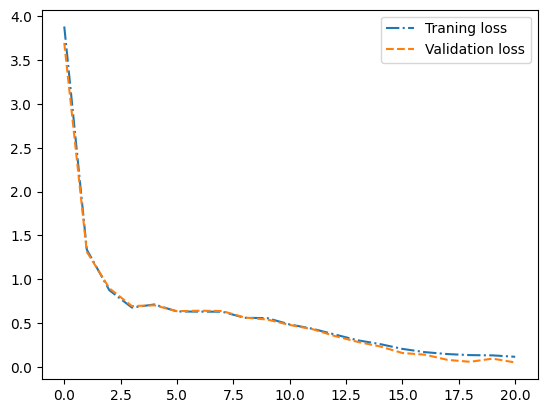

In [27]:
ax = pl.subplots()[1]
ax.plot(train_losses, label="Traning loss", linestyle="-.")
ax.plot(valid_losses, label="Validation loss", linestyle="--")
ax.legend()

# train_losses

In [18]:
tr.save(model.state_dict(), "sms_classification.pth")